# Тренирање модела – Класификација метал поджанрова
**Предмет:** Софтверски алгоритми у системима аутоматског управљања  
**Студент:** Марко Дурић РА 106-2023  
**Тема:** Вишекласна класификација метал поджанрова на основу аудио карактеристика

---

## Корак 1 – Увоз библиотека и учитавање припремљених података

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings("ignore")

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Učitavanje train/test setova
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test  = pd.read_csv("../data/processed/X_test.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_test  = pd.read_csv("../data/processed/y_test.csv").squeeze()

# Učitavanje label encodera
le = joblib.load("../models/label_encoder.pkl")
class_names = le.classes_

print("Train:", X_train.shape)
print("Test: ", X_test.shape)
print("Класе:", class_names)

Train: (760, 15)
Test:  (190, 15)
Класе: ['black-metal' 'death-metal' 'symphonic-metal' 'thrash-metal']


## Корак 2 – Помоћне функције за евалуацију

In [12]:
# Рјечник за чување резултата свих модела
results = {}

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, class_names):

    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, average="weighted")
    rec  = recall_score(y_te, y_pred, average="weighted")
    f1   = f1_score(y_te, y_pred, average="weighted")

    # K-fold cross validation (k=5, stratified)
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model, X_tr, y_tr, cv=skf, scoring="accuracy")

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1-score:  {f1:.4f}")
    print(f"  K-Fold CV: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    print()
    print(classification_report(y_te, y_pred, target_names=class_names))

    # Confusion matrica
    cm = confusion_matrix(y_te, y_pred)
    fig, ax = plt.subplots(figsize=(7, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, colorbar=True, cmap="Blues")
    ax.set_title(f"Confusion матрица – {name}", fontsize=13)
    plt.tight_layout()
    plt.show()

    # Čuvamo rezultate
    results[name] = {
        "Accuracy":  round(acc, 4),
        "Precision": round(prec, 4),
        "Recall":    round(rec, 4),
        "F1-score":  round(f1, 4),
        "CV Mean":   round(cv_scores.mean(), 4),
        "CV Std":    round(cv_scores.std(), 4)
    }

    return model



## Корак 3 – Baseline модел: Логистичка регресија


  Логистичка регресија
  Accuracy:  0.5842
  Precision: 0.5888
  Recall:    0.5842
  F1-score:  0.5808
  K-Fold CV: 0.5184 ± 0.0668

                 precision    recall  f1-score   support

    black-metal       0.58      0.76      0.66        50
    death-metal       0.52      0.52      0.52        50
symphonic-metal       0.67      0.51      0.58        43
   thrash-metal       0.60      0.53      0.56        47

       accuracy                           0.58       190
      macro avg       0.59      0.58      0.58       190
   weighted avg       0.59      0.58      0.58       190



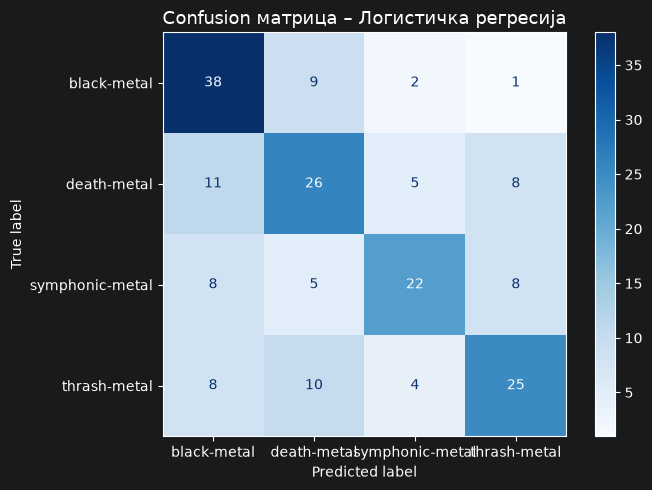

Модел сачуван: models/logistic_regression.pkl


In [13]:
lr = LogisticRegression(
    max_iter=1000,
    random_state=42,
    solver="lbfgs"
)

lr_model = evaluate_model(
    "Логистичка регресија",
    lr, X_train, y_train, X_test, y_test, class_names
)

joblib.dump(lr_model, "../models/logistic_regression.pkl")
print("Модел сачуван: models/logistic_regression.pkl")

## Корак 4 – Одабир оптималног K за KNN

Оптимални K: 1 (CV Accuracy: 0.5868)


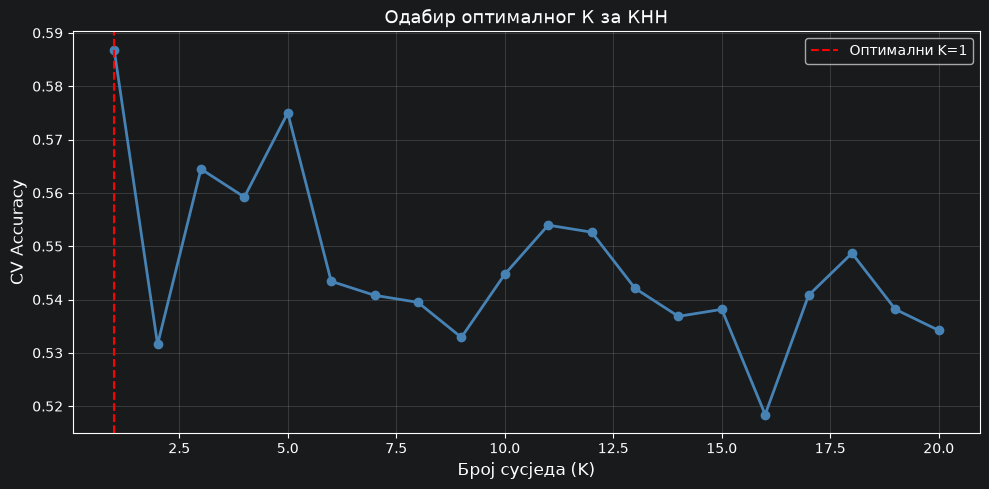

In [14]:
# Тестирамо К од 1 до 20 да нађемо оптималан број сусједа
k_range = range(1, 21)
k_scores = []

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train, y_train, cv=skf, scoring="accuracy")
    k_scores.append(scores.mean())

best_k = k_range[np.argmax(k_scores)]
print(f"Оптимални K: {best_k} (CV Accuracy: {max(k_scores):.4f})")

plt.figure(figsize=(10, 5))
plt.plot(k_range, k_scores, marker="o", color="steelblue", linewidth=2)
plt.axvline(x=best_k, color="red", linestyle="--", label=f"Оптимални K={best_k}")
plt.xlabel("Број сусједа (K)", fontsize=12)
plt.ylabel("CV Accuracy", fontsize=12)
plt.title("Одабир оптималног К за КНН", fontsize=13)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Корак 5 – Baseline модел: KNN


  КНН (K=1)
  Accuracy:  0.6316
  Precision: 0.6331
  Recall:    0.6316
  F1-score:  0.6308
  K-Fold CV: 0.5868 ± 0.0315

                 precision    recall  f1-score   support

    black-metal       0.57      0.50      0.53        50
    death-metal       0.44      0.48      0.46        50
symphonic-metal       0.80      0.74      0.77        43
   thrash-metal       0.75      0.83      0.79        47

       accuracy                           0.63       190
      macro avg       0.64      0.64      0.64       190
   weighted avg       0.63      0.63      0.63       190



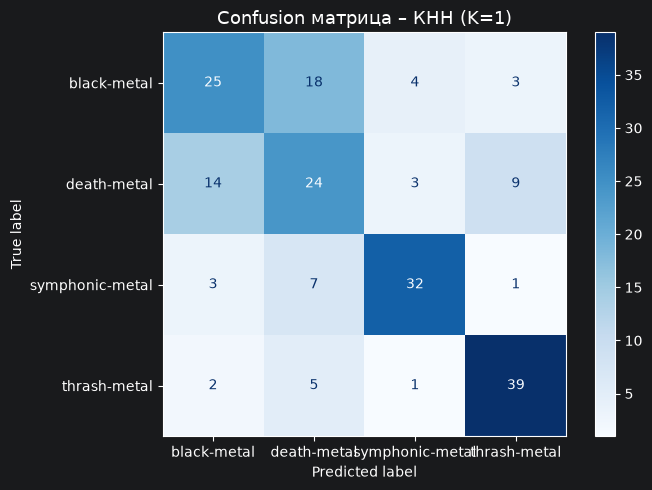

Модел сачуван: models/knn.pkl


In [15]:
knn = KNeighborsClassifier(n_neighbors=best_k)

knn_model = evaluate_model(
    f"КНН (K={best_k})",
    knn, X_train, y_train, X_test, y_test, class_names
)

joblib.dump(knn_model, "../models/knn.pkl")
print("Модел сачуван: models/knn.pkl")

## Корак 6 – Поређење baseline модела

Poređenje baseline modela:
                      Accuracy  Precision  Recall  F1-score  CV Mean  CV Std
Логистичка регресија    0.5842     0.5888  0.5842    0.5808   0.5184  0.0668
КНН (K=1)               0.6316     0.6331  0.6316    0.6308   0.5868  0.0315


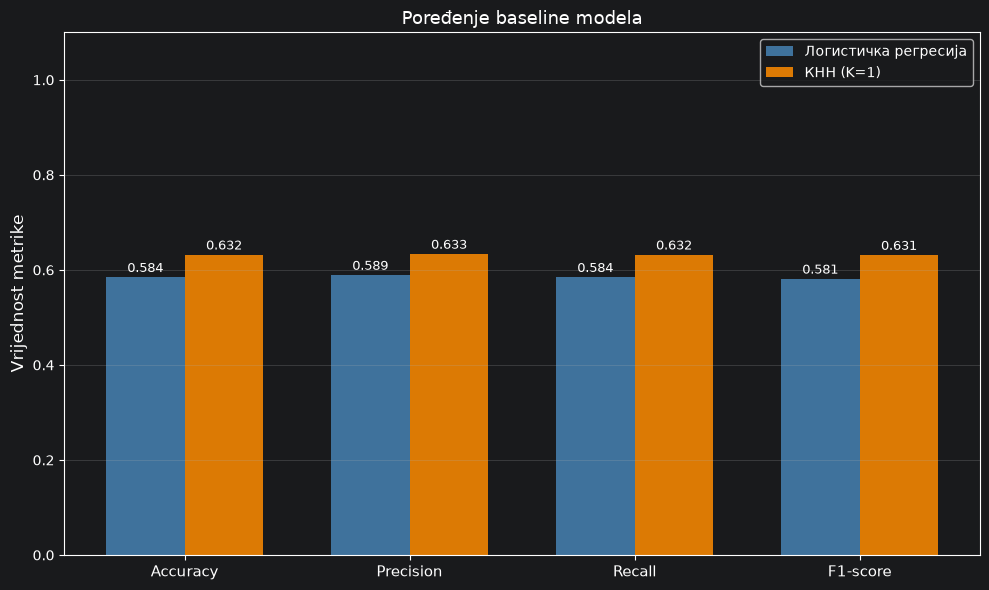

In [16]:
results_df = pd.DataFrame(results).T
print("Poređenje baseline modela:")
print(results_df.to_string())

# Vizualizacija
metrics = ["Accuracy", "Precision", "Recall", "F1-score"]
x = np.arange(len(metrics))
width = 0.35
colors = ["steelblue", "darkorange"]

fig, ax = plt.subplots(figsize=(10, 6))

for i, (model_name, row) in enumerate(results_df.iterrows()):
    vals = [row[m] for m in metrics]
    offset = (i - len(results_df) / 2 + 0.5) * width
    bars = ax.bar(x + offset, vals, width, label=model_name, color=colors[i], alpha=0.85)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{val:.3f}", ha="center", va="bottom", fontsize=9)

ax.set_ylabel("Vrijednost metrike", fontsize=12)
ax.set_title("Poređenje baseline modela", fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1.1)
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Корак 7 – Напредни модел: Random Forest


  Random Forest
  Accuracy:  0.7842
  Precision: 0.7964
  Recall:    0.7842
  F1-score:  0.7881
  K-Fold CV: 0.7461 ± 0.0472

                 precision    recall  f1-score   support

    black-metal       0.76      0.78      0.77        50
    death-metal       0.63      0.72      0.67        50
symphonic-metal       0.86      0.84      0.85        43
   thrash-metal       0.95      0.81      0.87        47

       accuracy                           0.78       190
      macro avg       0.80      0.79      0.79       190
   weighted avg       0.80      0.78      0.79       190



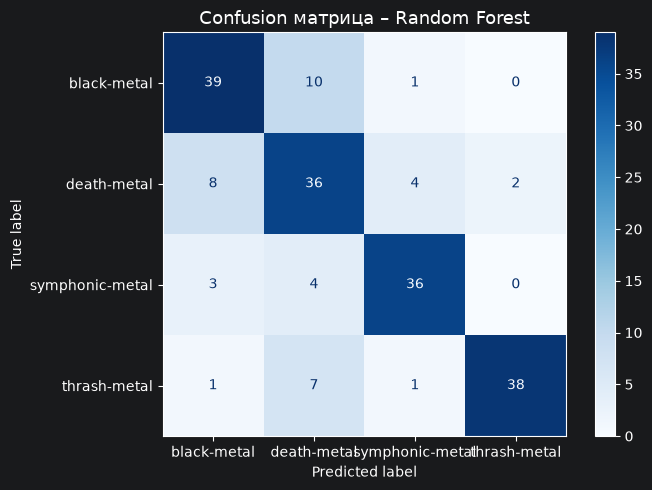

Модел сачуван: models/random_forest.pkl


In [17]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf_model = evaluate_model(
    "Random Forest",
    rf, X_train, y_train, X_test, y_test, class_names
)

joblib.dump(rf_model, "../models/random_forest.pkl")
print("Модел сачуван: models/random_forest.pkl")

## Корак 8 – Важност атрибута (Random Forest)

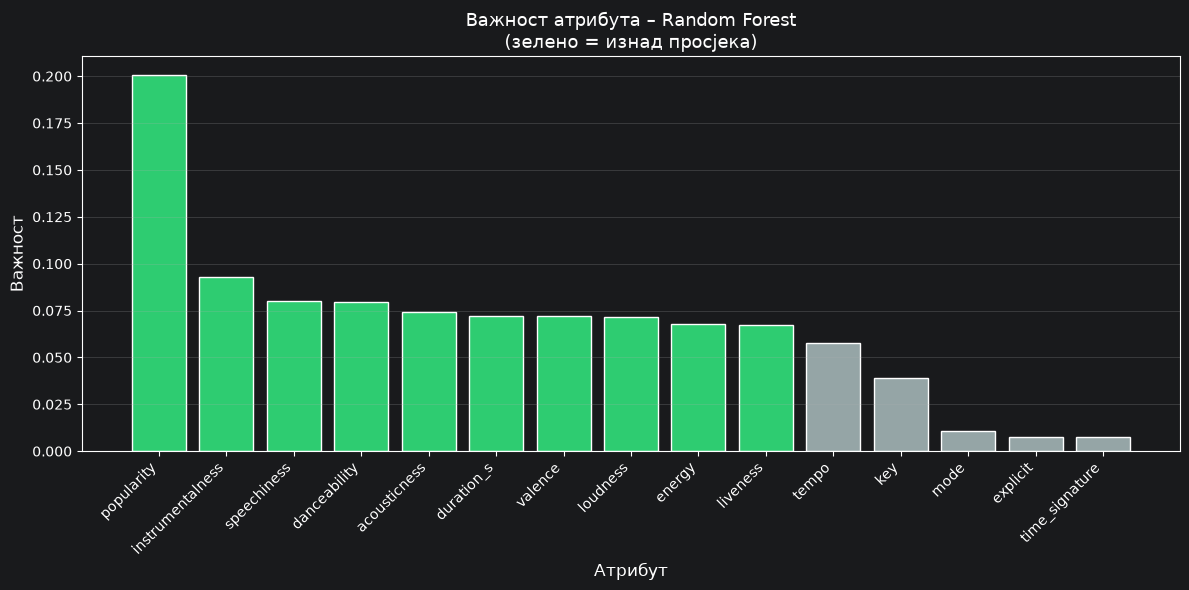

Топ 5 најважнијих атрибута:
  popularity: 0.2006
  instrumentalness: 0.0927
  speechiness: 0.0802
  danceability: 0.0796
  acousticness: 0.0741


In [18]:
feature_names = X_train.columns.tolist()
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 6))
colors = ["#2ecc71" if importances[i] >= np.mean(importances) else "#95a5a6" for i in indices]
plt.bar(range(len(feature_names)), importances[indices], color=colors, edgecolor="white")
plt.xticks(range(len(feature_names)), [feature_names[i] for i in indices], rotation=45, ha="right", fontsize=10)
plt.xlabel("Атрибут", fontsize=12)
plt.ylabel("Важност", fontsize=12)
plt.title("Важност атрибута – Random Forest\n(зелено = изнад просјека)", fontsize=13)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print("Топ 5 најважнијих атрибута:")
for i in indices[:5]:
    print(f"  {feature_names[i]}: {importances[i]:.4f}")

## Корак 9 – Напредни модел: SVM


  SVM (RBF kernel)
  Accuracy:  0.7105
  Precision: 0.7124
  Recall:    0.7105
  F1-score:  0.7068
  K-Fold CV: 0.6329 ± 0.0491

                 precision    recall  f1-score   support

    black-metal       0.62      0.78      0.69        50
    death-metal       0.62      0.48      0.54        50
symphonic-metal       0.79      0.77      0.78        43
   thrash-metal       0.85      0.83      0.84        47

       accuracy                           0.71       190
      macro avg       0.72      0.71      0.71       190
   weighted avg       0.71      0.71      0.71       190



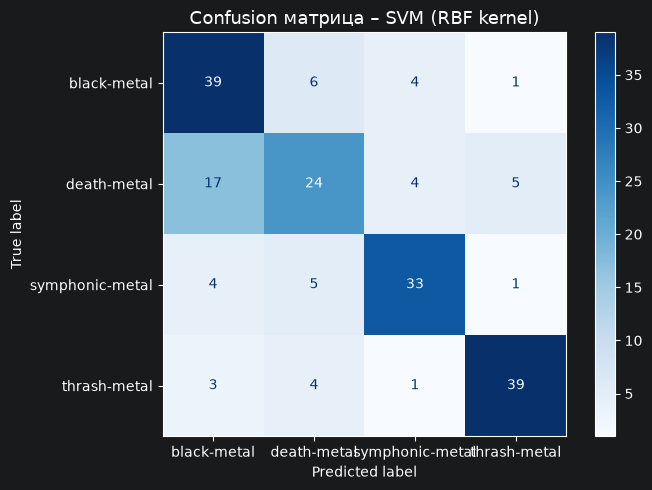

Model sacuvan: models/svm.pkl


In [19]:
from sklearn.svm import SVC

svm = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    random_state=42,
    probability=True
)

svm_model = evaluate_model(
    "SVM (RBF kernel)",
    svm, X_train, y_train, X_test, y_test, class_names
)

joblib.dump(svm_model, "../models/svm.pkl")
print("Model sacuvan: models/svm.pkl")

## Корак 10 – Напредни модел: XGBoost


  XGBoost
  Accuracy:  0.8105
  Precision: 0.8262
  Recall:    0.8105
  F1-score:  0.8146
  K-Fold CV: 0.7395 ± 0.0327

                 precision    recall  f1-score   support

    black-metal       0.79      0.82      0.80        50
    death-metal       0.67      0.80      0.73        50
symphonic-metal       0.92      0.79      0.85        43
   thrash-metal       0.95      0.83      0.89        47

       accuracy                           0.81       190
      macro avg       0.83      0.81      0.82       190
   weighted avg       0.83      0.81      0.81       190



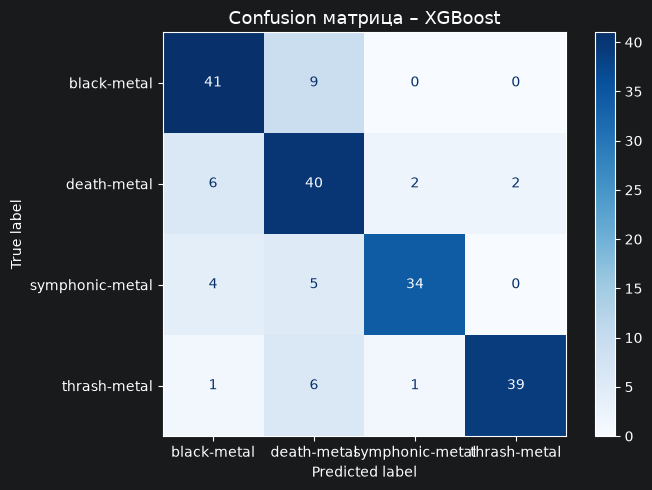

Model sacuvan: models/xgboost.pkl


In [20]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric="mlogloss",
    verbosity=0
)

xgb_model = evaluate_model(
    "XGBoost",
    xgb, X_train, y_train, X_test, y_test, class_names
)

joblib.dump(xgb_model, "../models/xgboost.pkl")
print("Model sacuvan: models/xgboost.pkl")

## Корак 11 – Финално поређење свих модела

Finalno poređenje svih modela:
                      Accuracy  Precision  Recall  F1-score  CV Mean  CV Std
Логистичка регресија    0.5842     0.5888  0.5842    0.5808   0.5184  0.0668
КНН (K=1)               0.6316     0.6331  0.6316    0.6308   0.5868  0.0315
Random Forest           0.7842     0.7964  0.7842    0.7881   0.7461  0.0472
SVM (RBF kernel)        0.7105     0.7124  0.7105    0.7068   0.6329  0.0491
XGBoost                 0.8105     0.8262  0.8105    0.8146   0.7395  0.0327


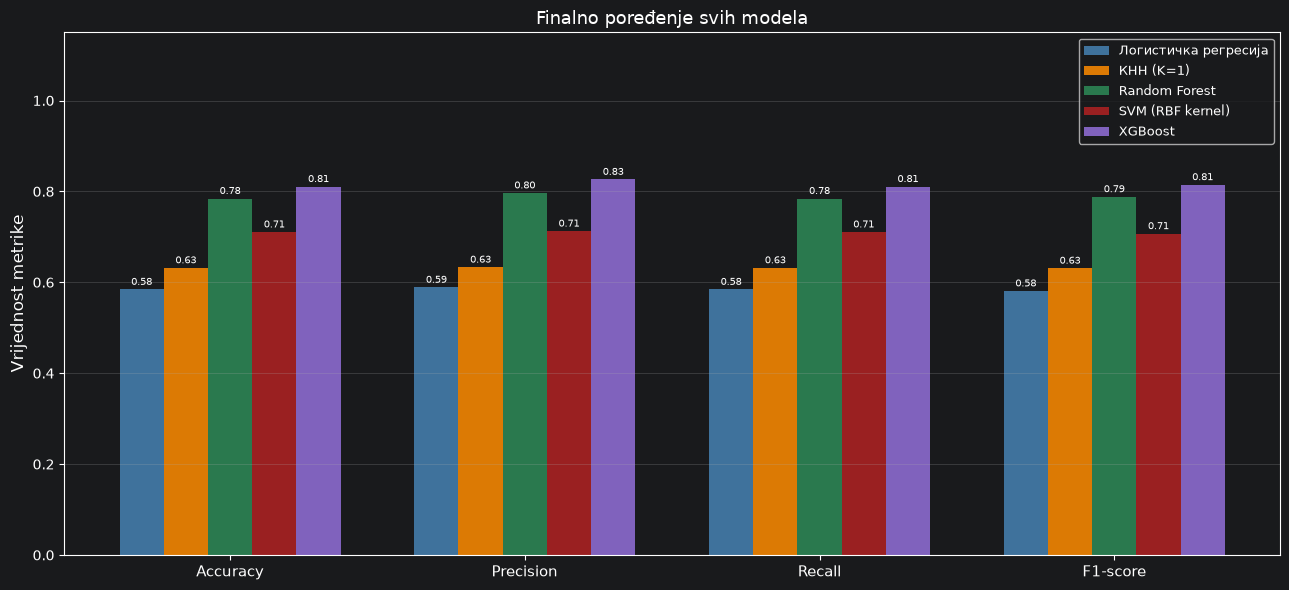

In [21]:
results_df = pd.DataFrame(results).T
print("Finalno poređenje svih modela:")
print(results_df.to_string())

# Bar chart – sve metrike, svi modeli
metrics = ["Accuracy", "Precision", "Recall", "F1-score"]
x = np.arange(len(metrics))
width = 0.15
colors = ["steelblue", "darkorange", "seagreen", "firebrick", "mediumpurple"]

fig, ax = plt.subplots(figsize=(13, 6))

for i, (model_name, row) in enumerate(results_df.iterrows()):
    vals = [row[m] for m in metrics]
    offset = (i - len(results_df) / 2 + 0.5) * width
    bars = ax.bar(x + offset, vals, width, label=model_name, color=colors[i], alpha=0.85)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{val:.2f}", ha="center", va="bottom", fontsize=7)

ax.set_ylabel("Vrijednost metrike", fontsize=12)
ax.set_title("Finalno poređenje svih modela", fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1.15)
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Корак 12 – К-fold поређење (CV Mean ± Std)

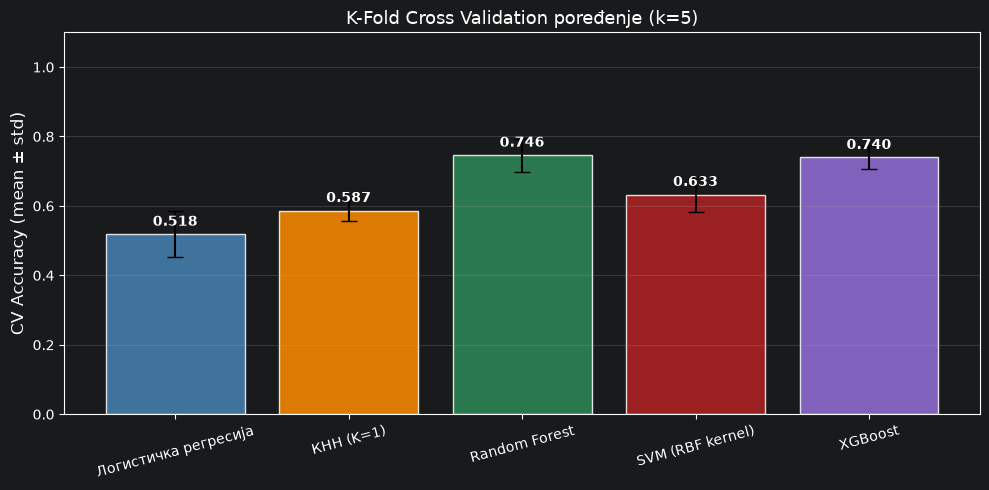

In [22]:
fig, ax = plt.subplots(figsize=(10, 5))

model_names = list(results_df.index)
cv_means = results_df["CV Mean"].values
cv_stds  = results_df["CV Std"].values
colors_cv = ["steelblue", "darkorange", "seagreen", "firebrick", "mediumpurple"]

bars = ax.bar(model_names, cv_means, yerr=cv_stds, capsize=6,
              color=colors_cv, alpha=0.85, edgecolor="white")

for bar, val in zip(bars, cv_means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.015,
            f"{val:.3f}", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_ylabel("CV Accuracy (mean ± std)", fontsize=12)
ax.set_title("K-Fold Cross Validation poređenje (k=5)", fontsize=13)
ax.set_ylim(0, 1.1)
ax.tick_params(axis="x", rotation=15)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Корак 13 – Закључци моделовања

In [23]:
best_model = results_df["F1-score"].idxmax()
best_f1    = results_df.loc[best_model, "F1-score"]
best_acc   = results_df.loc[best_model, "Accuracy"]
best_cv    = results_df.loc[best_model, "CV Mean"]

print("=" * 55)
print("  ZAKLJUCCI MODELOVANJA")
print("=" * 55)
print()
print(f"  Najbolji model: {best_model}")
print(f"  Accuracy:       {best_acc:.4f}")
print(f"  F1-score:       {best_f1:.4f}")
print(f"  CV Accuracy:    {best_cv:.4f}")
print()
print("  Poređenje svih modela (sortirano po F1):")
print(results_df.sort_values("F1-score", ascending=False)[
    ["Accuracy", "F1-score", "CV Mean", "CV Std"]
].to_string())
print()
print("  Najčešća konfuzija: black-metal <-> death-metal")
print("  (potvrđeno u EDA – najveće preklapanje KDE distribucija)")

  ZAKLJUCCI MODELOVANJA

  Najbolji model: XGBoost
  Accuracy:       0.8105
  F1-score:       0.8146
  CV Accuracy:    0.7395

  Poređenje svih modela (sortirano po F1):
                      Accuracy  F1-score  CV Mean  CV Std
XGBoost                 0.8105    0.8146   0.7395  0.0327
Random Forest           0.7842    0.7881   0.7461  0.0472
SVM (RBF kernel)        0.7105    0.7068   0.6329  0.0491
КНН (K=1)               0.6316    0.6308   0.5868  0.0315
Логистичка регресија    0.5842    0.5808   0.5184  0.0668

  Najčešća konfuzija: black-metal <-> death-metal
  (potvrđeno u EDA – najveće preklapanje KDE distribucija)
